In [2]:
import cv2
import numpy as np
from skimage.morphology import skeletonize, dilation, square
from skimage import data
from matplotlib import pyplot as plt
import math

In [5]:
### SPOT IMAGES ARE 640x480 (WxH) ###

def start(img):
    hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    lower_red1 = np.array([0, 120, 70])
    upper_red1 = np.array([10, 255, 255])
    mask_red1 = cv2.inRange(hsv_image, lower_red1, upper_red1)

    lower_red2 = np.array([170, 120, 70])
    upper_red2 = np.array([180, 255, 255])
    mask_red2 = cv2.inRange(hsv_image, lower_red2, upper_red2)

    mask_red = mask_red1 + mask_red2

    result_image = cv2.bitwise_and(img, img, mask=mask_red)

    img = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)
    image = img.copy()

    # Convert mask_red to a format compatible with cvtColor
    plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    plt.show()

    gray_img = cv2.cvtColor(result_image, cv2.COLOR_RGB2GRAY)

    _, black_white = cv2.threshold(gray_img, 1, 255, cv2.THRESH_BINARY)

    blur = cv2.GaussianBlur(black_white, (9,9), 0)

    contours, _ = cv2.findContours(blur, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # canny = cv2.Canny(blur,100,200)


    # Initialize variables to store the largest horizontal line
    max_width = 0
    best_bbox = None
    cv2.drawContours(image, contours, -1, (255,255, 255), 1)  # Blue color in BGR


    # Iterate through contours to find the longest horizontal line
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if w > max_width:
            max_width = w
            best_bbox = (x, y, x + w, y + h)

    # Draw the bounding box on the image
    if best_bbox:
        cv2.rectangle(image, (best_bbox[0], best_bbox[1]), (best_bbox[2], best_bbox[3]), (0, 0, 255), 2)  # Red color in BGR
        center_x = (best_bbox[0] + best_bbox[2]) // 2
        center_y = (best_bbox[1] + best_bbox[3]) // 2

        cv2.circle(image, (center_x, center_y), 5, (0, 255, 0), 2)
        print(f"Coordinates: ({center_x},{center_y})")

    plt.imshow(image)
    plt.show()
    
    # # Normalize the image to range [0, 1] for skeletonization
    # black_white_norm = black_white // 255

    # skel_img = skeletonize(black_white_norm).astype(np.uint8)

    # dilated_skeleton = dilation(skel_img, square(3))

    # plt.title("Skeletonized Image")
    # plt.imshow(dilated_skeleton, cmap='gray')
    # plt.axis('off')
    # plt.show()

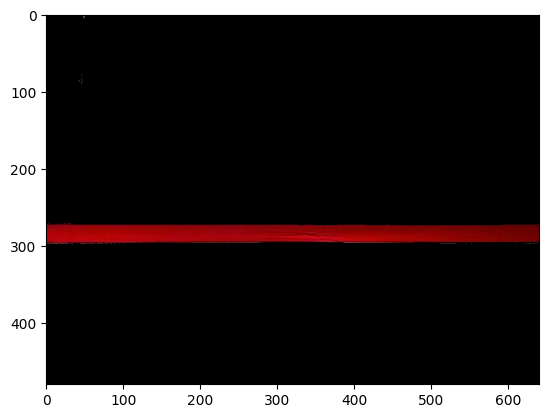

Coordinates: (320,284)


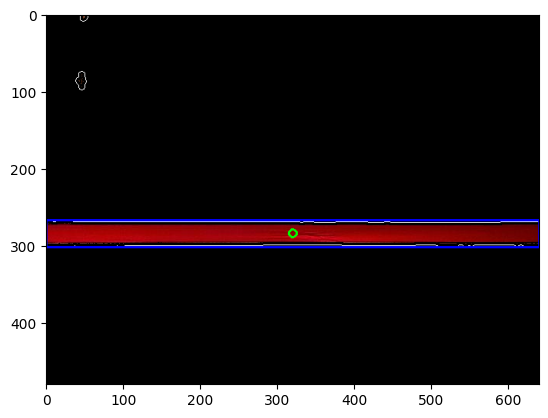

In [7]:
if __name__ == '__main__':
    img = cv2.imread('/Users/sagar/Documents/GitHub/BDSpot/hand_color_image1.jpg')
    if img is not None:
        start(img)
    else:
        print("Error: Image not found")